# DeepSeek-R1-0528-Qwen3-8B — C Coding Fine-Tuning Experiment

**Hardware**: Tesla T4 16 GB  
**Goal**: Compare QLoRA fine-tuning via HuggingFace Transformers vs Unsloth, with/without DeepSpeed.

## Experiment Flow
1. Package imports
2. Logging setup  ← **new: all output saved to `logs/experiment_<timestamp>.log`**
3. Working directory + path setup
4. Dataset inspection
5. Baseline evaluation (pre fine-tuning)
6. Fine-tuning — HF Transformers (no DeepSpeed)
7. Fine-tuning — HF Transformers + DeepSpeed ZeRO-2
8. Fine-tuning — Unsloth
9. Post fine-tuning evaluation for all three checkpoints
10. Metrics comparison table and charts
11. View saved log file

In [2]:
!pip install trl bitsandbytes evaluate sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 14.2 MB/s eta 0:00:00


## Cell 1 — Package Imports

In [3]:
# ── Standard library ──────────────────────────────────────────────────────
import json
import logging
import os
import pathlib
import subprocess
import sys
import threading
import time

# ── PyTorch ───────────────────────────────────────────────────────────────
import torch

# ── HuggingFace ecosystem ──────────────────────────────────────────────────
import transformers
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
import peft
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
import datasets
from datasets import Dataset
import trl
from trl import SFTTrainer
import accelerate
import bitsandbytes

# ── Evaluation ────────────────────────────────────────────────────────────
import evaluate as hf_evaluate
import sacrebleu

# ── Data / Visualisation ──────────────────────────────────────────────────
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML

print("All imports successful.")

All imports successful.


## Cell 2 — Logging Setup

Creates a logger that:
- **Prints every message to the notebook** (so you see it live)
- **Saves every message to `logs/experiment_<timestamp>.log`** (so you can review it later)

Format: `[HH:MM:SS] [LEVEL] [stage] message`

Use `log.info(...)`, `log.debug(...)`, `log.warning(...)`, `log.error(...)` throughout the notebook.

In [4]:
# ── Create logs/ directory ────────────────────────────────────────────────
# We use pathlib.Path.cwd() here; PROJECT_ROOT is set in the next cell.
# The log file will be moved/referenced again after CWD is confirmed.
_LOG_DIR = pathlib.Path.cwd() / "logs"
_LOG_DIR.mkdir(exist_ok=True)

RUN_TIMESTAMP = time.strftime("%Y%m%d_%H%M%S")
LOG_FILE = _LOG_DIR / f"experiment_{RUN_TIMESTAMP}.log"

# ── Build logger ──────────────────────────────────────────────────────────
# Remove any handlers left over from a previous kernel run
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

log = logging.getLogger("experiment")
log.setLevel(logging.DEBUG)
log.handlers.clear()

FMT = logging.Formatter(
    fmt="[%(asctime)s] [%(levelname)-7s] %(message)s",
    datefmt="%H:%M:%S",
)

# Handler 1: file — captures everything (DEBUG+)
_fh = logging.FileHandler(LOG_FILE, mode="w", encoding="utf-8")
_fh.setLevel(logging.DEBUG)
_fh.setFormatter(FMT)
log.addHandler(_fh)

# Handler 2: notebook stdout — shows INFO+ (not DEBUG noise by default)
_sh = logging.StreamHandler(sys.stdout)
_sh.setLevel(logging.INFO)
_sh.setFormatter(FMT)
log.addHandler(_sh)

log.info(f"Logging initialised. Run timestamp : {RUN_TIMESTAMP}")
log.info(f"Log file          : {LOG_FILE}")
log.debug("DEBUG messages are written to the log file but NOT shown in the notebook.")
log.info("INFO  messages are shown in the notebook AND saved to the log file.")
log.warning("WARNING messages are shown in the notebook AND saved to the log file.")

[09:45:50] [INFO   ] Logging initialised. Run timestamp : 20260408_094550
[09:45:50] [INFO   ] Log file          : /content/logs/experiment_20260408_094550.log
[09:45:50] [INFO   ] INFO  messages are shown in the notebook AND saved to the log file.
[09:45:50] [WARNING] WARNING messages are shown in the notebook AND saved to the log file.


## Cell 3 — Working Directory + Path Setup
Anchors the notebook to the project root and sets all paths as absolute variables.

In [6]:
def find_project_root(marker: str = "data/c_coding_dataset.json") -> pathlib.Path:
    """Walk up from CWD until marker file is found."""
    candidate = pathlib.Path.cwd()
    for _ in range(6):
        if (candidate / marker).exists():
            return candidate
        candidate = candidate.parent
    raise FileNotFoundError(
        f"Project root not found (looked for '{marker}' up to 6 levels). "
        "Open the notebook from inside the project directory."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

# Re-point log file to project root's logs/ in case CWD changed
LOG_FILE = PROJECT_ROOT / "logs" / f"experiment_{RUN_TIMESTAMP}.log"
(PROJECT_ROOT / "logs").mkdir(exist_ok=True)
# Redirect the file handler to the correct path
for _h in log.handlers:
    if isinstance(_h, logging.FileHandler):
        _h.stream.close()
        _h.baseFilename = str(LOG_FILE)
        _h.stream = open(str(LOG_FILE), "a", encoding="utf-8")

# ── Absolute paths used by every subsequent cell ──────────────────────────
DATASET_PATH    = PROJECT_ROOT / "data"   / "c_coding_dataset.json"
EVALUATE_SCRIPT = PROJECT_ROOT / "evaluate.py"
FT_TRANS_SCRIPT = PROJECT_ROOT / "finetune_transformers.py"
FT_UNS_SCRIPT   = PROJECT_ROOT / "finetune_unsloth.py"
DS_CONFIG       = PROJECT_ROOT / "configs" / "ds_config.json"
LOGS_DIR        = PROJECT_ROOT / "logs"

log.info(f"PROJECT_ROOT     : {PROJECT_ROOT}")
log.info(f"CWD              : {os.getcwd()}")
log.info(f"Log file         : {LOG_FILE}")

# Verify critical files exist
checks = {
    "Dataset": DATASET_PATH,
    "evaluate.py": EVALUATE_SCRIPT,
    "finetune_transformers.py": FT_TRANS_SCRIPT,
    "finetune_unsloth.py": FT_UNS_SCRIPT,
    "ds_config.json": DS_CONFIG,
}
all_ok = True
for name, path in checks.items():
    exists = path.exists()
    status = "OK" if exists else "MISSING"
    if exists:
        log.info(f"  [{status}] {name} -> {path}")
    else:
        log.error(f"  [{status}] {name} -> {path}")
        all_ok = False

if not all_ok:
    log.error("One or more required files are missing. Check your project structure.")
else:
    log.info("All required files found. Ready to run.")

[09:48:58] [INFO   ] PROJECT_ROOT     : /content
[09:48:58] [INFO   ] CWD              : /content
[09:48:58] [INFO   ] Log file         : /content/logs/experiment_20260408_094550.log
[09:48:58] [INFO   ]   [OK] Dataset -> /content/data/c_coding_dataset.json
[09:48:58] [INFO   ]   [OK] evaluate.py -> /content/evaluate.py
[09:48:58] [INFO   ]   [OK] finetune_transformers.py -> /content/finetune_transformers.py
[09:48:58] [INFO   ]   [OK] finetune_unsloth.py -> /content/finetune_unsloth.py
[09:48:58] [INFO   ]   [OK] ds_config.json -> /content/configs/ds_config.json
[09:48:58] [INFO   ] All required files found. Ready to run.


## Cell 4 — Subprocess & Helper Functions

Key design: training takes minutes. `run_streaming_subprocess` uses `Popen` to print each line  
**as it arrives** rather than waiting for the process to finish, so you see real-time progress.

In [7]:
def run_streaming_subprocess(cmd: list, label: str) -> int:
    """
    Run `cmd` with CWD=PROJECT_ROOT and stream stdout/stderr line-by-line.

    Every line is:
      - printed immediately to the notebook (so you see training progress live)
      - saved to the log file via log.debug()

    Returns the process exit code.
    """
    log.info(f"[{label}] ── START ──────────────────────────────────────")
    log.info(f"[{label}] Command : {' '.join(str(c) for c in cmd)}")
    log.info(f"[{label}] CWD     : {PROJECT_ROOT}")
    t0 = time.time()

    proc = subprocess.Popen(
        [str(c) for c in cmd],
        cwd=str(PROJECT_ROOT),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,   # merge stderr into stdout so order is preserved
        text=True,
        bufsize=1,                  # line-buffered
    )

    # Stream output line by line
    for raw_line in proc.stdout:
        line = raw_line.rstrip()
        if line:                    # skip blank lines in notebook output
            print(f"  {line}", flush=True)
            log.debug(f"[{label}] {line}")   # full detail in log file

    proc.wait()
    elapsed = time.time() - t0

    if proc.returncode == 0:
        log.info(f"[{label}] ── SUCCESS  (exit 0) | wall time: {elapsed:.1f}s ──")
    else:
        log.error(
            f"[{label}] ── FAILED   (exit {proc.returncode}) | wall time: {elapsed:.1f}s ──"
        )
        log.error(f"[{label}] Tip: scroll up or open {LOG_FILE} for the full output.")

    return proc.returncode


def run_evaluate(model_path: str | pathlib.Path, output_file: str) -> dict:
    """
    Run evaluate.py as a streaming subprocess.
    Returns the parsed metrics dict, or {} on failure.
    """
    abs_output = str(PROJECT_ROOT / output_file)
    cmd = [
        sys.executable, EVALUATE_SCRIPT,
        "--model_path",   str(model_path),
        "--dataset_path", str(DATASET_PATH),
        "--output",       abs_output,
        "--split",        "eval",
    ]
    log.info(f"[evaluate] Model  : {model_path}")
    log.info(f"[evaluate] Output : {abs_output}")

    exit_code = run_streaming_subprocess(cmd, "evaluate")

    if exit_code != 0 or not pathlib.Path(abs_output).exists():
        log.error("[evaluate] Result file not created — returning empty metrics.")
        return {}

    with open(abs_output) as f:
        metrics = json.load(f)
    log.info(f"[evaluate] pass_at_1={metrics.get('pass_at_1')}  "
             f"bleu4={metrics.get('bleu4')}  "
             f"exact_match={metrics.get('exact_match')}")
    return metrics


def load_run_meta(checkpoint_dir: str) -> dict:
    """
    Load run_meta.json written by a fine-tuning script.
    Returns {} with a log message if the file is missing.
    """
    meta_path = PROJECT_ROOT / checkpoint_dir / "run_meta.json"
    if not meta_path.exists():
        log.warning(f"[meta] {meta_path} not found — fine-tuning may have failed.")
        return {}
    with open(meta_path) as f:
        meta = json.load(f)
    log.info(f"[meta] Loaded from {meta_path}")
    for k, v in meta.items():
        log.debug(f"[meta]   {k}: {v}")
    return meta


def log_gpu_state(label: str = "") -> None:
    """Log current GPU memory usage (requires CUDA)."""
    if not torch.cuda.is_available():
        log.debug("[gpu] CUDA not available — skipping GPU state log")
        return
    alloc_mb  = torch.cuda.memory_allocated()  / 1024**2
    reserv_mb = torch.cuda.memory_reserved()   / 1024**2
    total_mb  = torch.cuda.get_device_properties(0).total_memory / 1024**2
    tag = f" [{label}]" if label else ""
    log.info(f"[gpu]{tag} allocated={alloc_mb:.0f} MB  "
             f"reserved={reserv_mb:.0f} MB  "
             f"total={total_mb:.0f} MB")


log.info("Helper functions defined: run_streaming_subprocess, run_evaluate, load_run_meta, log_gpu_state")

[09:49:59] [INFO   ] Helper functions defined: run_streaming_subprocess, run_evaluate, load_run_meta, log_gpu_state


## Cell 5 — Environment & GPU Diagnostics

In [8]:
log.info("── Environment diagnostics ─────────────────────────────")
log.info(f"Python          : {sys.version.split()[0]}")
log.info(f"PyTorch         : {torch.__version__}")
log.info(f"transformers    : {transformers.__version__}")
log.info(f"peft            : {peft.__version__}")
log.info(f"datasets        : {datasets.__version__}")
log.info(f"trl             : {trl.__version__}")
log.info(f"accelerate      : {accelerate.__version__}")
log.info(f"bitsandbytes    : {bitsandbytes.__version__}")
log.info(f"matplotlib      : {matplotlib.__version__}")

log.info("── CUDA diagnostics ────────────────────────────────────")
cuda_ok = torch.cuda.is_available()
log.info(f"CUDA available  : {cuda_ok}")
if cuda_ok:
    log.info(f"GPU name        : {torch.cuda.get_device_name(0)}")
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    log.info(f"VRAM total      : {total_gb:.1f} GB")
    if total_gb < 14:
        log.warning("VRAM < 14 GB — may OOM during training. Consider reducing max_seq_length to 256.")
    else:
        log.info("VRAM looks sufficient for 4-bit QLoRA on 8B model.")
    log_gpu_state("startup")
else:
    log.warning("No CUDA GPU detected. Training will fail. Evaluation in CPU mode will be very slow.")

[09:51:20] [INFO   ] ── Environment diagnostics ─────────────────────────────
[09:51:20] [INFO   ] Python          : 3.12.13
[09:51:20] [INFO   ] PyTorch         : 2.10.0+cu128
[09:51:20] [INFO   ] transformers    : 5.0.0
[09:51:20] [INFO   ] peft            : 0.18.1
[09:51:20] [INFO   ] datasets        : 4.8.4
[09:51:20] [INFO   ] trl             : 1.0.0
[09:51:20] [INFO   ] accelerate      : 1.13.0
[09:51:20] [INFO   ] bitsandbytes    : 0.49.2
[09:51:20] [INFO   ] matplotlib      : 3.10.0
[09:51:20] [INFO   ] ── CUDA diagnostics ────────────────────────────────────
[09:51:20] [INFO   ] CUDA available  : True
[09:51:20] [INFO   ] GPU name        : Tesla T4
[09:51:20] [INFO   ] VRAM total      : 15.6 GB
[09:51:20] [INFO   ] VRAM looks sufficient for 4-bit QLoRA on 8B model.
[09:51:20] [INFO   ] [gpu] [startup] allocated=0 MB  reserved=0 MB  total=14913 MB


## Cell 6 — Dataset Inspection

In [9]:
log.info("── Loading dataset ─────────────────────────────────────")
log.info(f"Dataset path : {DATASET_PATH}")

with open(DATASET_PATH) as f:
    raw_data = json.load(f)

train_samples = raw_data["train"]
eval_samples  = raw_data["eval"]
log.info(f"Train samples : {len(train_samples)}")
log.info(f"Eval  samples : {len(eval_samples)}")

# Schema validation
required_keys = {"instruction", "input", "output"}
bad = [i for i, s in enumerate(train_samples + eval_samples) if not required_keys.issubset(s)]
if bad:
    log.error(f"Samples with missing keys at indices: {bad}")
else:
    log.info("Schema check passed: all samples have {instruction, input, output}.")

# Token length distribution (rough estimate: chars / 4)
lengths = [len(s["output"]) // 4 for s in train_samples]
log.info(f"Output length (tokens, est.) — min:{min(lengths)}  max:{max(lengths)}  mean:{sum(lengths)//len(lengths)}")
log.debug(f"All estimated output lengths: {lengths}")

print("\n--- Example train sample (index 0) ---")
ex = train_samples[0]
print(f"Instruction : {ex['instruction']}")
print(f"Output (first 300 chars):\n{ex['output'][:300]}...")

[09:51:58] [INFO   ] ── Loading dataset ─────────────────────────────────────
[09:51:58] [INFO   ] Dataset path : /content/data/c_coding_dataset.json
[09:51:58] [INFO   ] Train samples : 50
[09:51:58] [INFO   ] Eval  samples : 10
[09:51:58] [INFO   ] Schema check passed: all samples have {instruction, input, output}.
[09:51:58] [INFO   ] Output length (tokens, est.) — min:51  max:251  mean:127

--- Example train sample (index 0) ---
Instruction : Write a C function that swaps two integers using pointers.
Output (first 300 chars):
#include <stdio.h>

void swap(int *a, int *b) {
    int temp = *a;
    *a = *b;
    *b = temp;
}

int main() {
    int x = 5, y = 10;
    swap(&x, &y);
    printf("x = %d, y = %d\n", x, y);
    return 0;
}...


[09:52:12] [INFO   ] ── Domain distribution analysis ────────────────────────
[09:52:12] [INFO   ]   Pointer     : 9 samples
[09:52:12] [INFO   ]   Memory      : 8 samples
[09:52:12] [INFO   ]   Algorithm   : 20 samples
[09:52:12] [INFO   ]   Struct      : 4 samples
[09:52:12] [INFO   ]   File I/O    : 8 samples


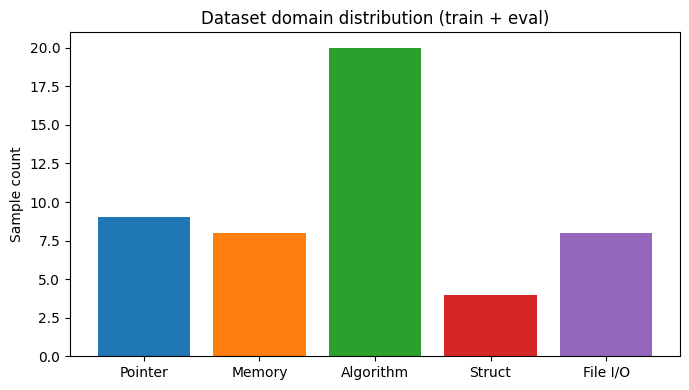

[09:52:12] [INFO   ] Dataset inspection complete.


In [10]:
log.info("── Domain distribution analysis ────────────────────────")
domain_keywords = {
    "Pointer":   ["pointer", "ptr", "dereference", "address"],
    "Memory":    ["malloc", "free", "memory", "heap", "allocat", "realloc"],
    "Algorithm": ["sort", "search", "algorithm", "binary", "linked list", "stack", "queue", "recursi"],
    "Struct":    ["struct", "typedef", "member"],
    "File I/O":  ["file", "fopen", "fclose", "fread", "fwrite", "fprintf", "fscanf"],
}
domain_counts = {d: 0 for d in domain_keywords}
for s in train_samples + eval_samples:
    instr = s["instruction"].lower()
    for domain, kws in domain_keywords.items():
        if any(k in instr for k in kws):
            domain_counts[domain] += 1
            break

for domain, count in domain_counts.items():
    log.info(f"  {domain:<12}: {count} samples")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(domain_counts.keys(), domain_counts.values(), color=sns.color_palette("tab10"))
ax.set_title("Dataset domain distribution (train + eval)")
ax.set_ylabel("Sample count")
plt.tight_layout()
plt.show()
log.info("Dataset inspection complete.")

## Cell 7 — Model & Experiment Configuration
Set `MODEL_NAME` here. Change to a local path if you have already downloaded the model.

In [13]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('HF_TOKEN')
login(hf_token)

In [11]:
MODEL_NAME     = "deepseek-ai/DeepSeek-R1-0528-Qwen3-8B"   # or local path
MAX_SEQ_LENGTH = 512

# Output directories (absolute paths)
OUT_TRANSFORMERS    = PROJECT_ROOT / "finetuned-transformers"
OUT_TRANSFORMERS_DS = PROJECT_ROOT / "finetuned-transformers-ds"
OUT_UNSLOTH         = PROJECT_ROOT / "finetuned-unsloth"

log.info("── Experiment configuration ────────────────────────────")
log.info(f"Model name        : {MODEL_NAME}")
log.info(f"Max seq length    : {MAX_SEQ_LENGTH}")
log.info(f"Out (no DS)       : {OUT_TRANSFORMERS}")
log.info(f"Out (DeepSpeed)   : {OUT_TRANSFORMERS_DS}")
log.info(f"Out (Unsloth)     : {OUT_UNSLOTH}")
log.info(f"DeepSpeed config  : {DS_CONFIG}")
log.info("Configuration logged. Proceed to evaluation / fine-tuning cells.")

[09:52:35] [INFO   ] ── Experiment configuration ────────────────────────────
[09:52:35] [INFO   ] Model name        : deepseek-ai/DeepSeek-R1-0528-Qwen3-8B
[09:52:35] [INFO   ] Max seq length    : 512
[09:52:35] [INFO   ] Out (no DS)       : /content/finetuned-transformers
[09:52:35] [INFO   ] Out (DeepSpeed)   : /content/finetuned-transformers-ds
[09:52:35] [INFO   ] Out (Unsloth)     : /content/finetuned-unsloth
[09:52:35] [INFO   ] DeepSpeed config  : /content/configs/ds_config.json
[09:52:35] [INFO   ] Configuration logged. Proceed to evaluation / fine-tuning cells.


## Cell 8 — Baseline Evaluation (pre fine-tuning)

What happens inside `evaluate.py`:
1. Load model in 4-bit NF4
2. For each of the 10 eval samples: format prompt → greedy decode → `gcc` compile check
3. Compute BLEU-4 (sacrebleu) and Exact Match
4. Write `results_baseline.json`

Each sample line is streamed to the notebook as it finishes.

In [14]:
log.info("════════════════════════════════════════════════════════")
log.info("STAGE: Baseline evaluation (base model, no fine-tuning)")
log.info("════════════════════════════════════════════════════════")
log_gpu_state("before baseline eval")

t_start = time.time()
baseline_metrics = run_evaluate(MODEL_NAME, "results_baseline.json")
t_elapsed = time.time() - t_start

log.info(f"Baseline evaluation finished in {t_elapsed:.1f}s")
if baseline_metrics:
    log.info("Baseline results summary:")
    for k, v in baseline_metrics.items():
        log.info(f"  {k}: {v}")
else:
    log.error("Baseline metrics empty — check the evaluate.py output above for errors.")

[10:03:46] [INFO   ] ════════════════════════════════════════════════════════
[10:03:46] [INFO   ] STAGE: Baseline evaluation (base model, no fine-tuning)
[10:03:46] [INFO   ] ════════════════════════════════════════════════════════
[10:03:46] [INFO   ] [gpu] [before baseline eval] allocated=0 MB  reserved=0 MB  total=14913 MB
[10:03:46] [INFO   ] [evaluate] Model  : deepseek-ai/DeepSeek-R1-0528-Qwen3-8B
[10:03:46] [INFO   ] [evaluate] Output : /content/results_baseline.json
[10:03:46] [INFO   ] [evaluate] ── START ──────────────────────────────────────
[10:03:46] [INFO   ] [evaluate] Command : /usr/bin/python3 /content/evaluate.py --model_path deepseek-ai/DeepSeek-R1-0528-Qwen3-8B --dataset_path /content/data/c_coding_dataset.json --output /content/results_baseline.json --split eval
[10:03:46] [INFO   ] [evaluate] CWD     : /content
  Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'attn_factor'}
  Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'attn_f

## Cell 9 — Fine-Tuning: HF Transformers (no DeepSpeed)

What `finetune_transformers.py` does step-by-step:
1. Load tokenizer from `MODEL_NAME`
2. Load model in 4-bit NF4 (`BitsAndBytesConfig`)
3. `prepare_model_for_kbit_training` — casts LayerNorms to fp32, enables gradient checkpointing
4. Inject LoRA adapters (r=8, α=16) on 7 projection modules
5. Format 50 train samples with the `### Instruction / Response` template
6. Run `SFTTrainer` for 3 epochs (effective batch=4, `paged_adamw_8bit`)
7. Save adapter weights + write `run_meta.json`

Training lines are streamed live. Look for `{'loss': ..., 'epoch': ...}` from HuggingFace Trainer.

In [16]:
log.info("════════════════════════════════════════════════════════")
log.info("STAGE: Fine-tuning — HF Transformers (no DeepSpeed)")
log.info("════════════════════════════════════════════════════════")
log.info("Why no DeepSpeed here: establishes a clean single-GPU baseline")
log.info("Optimizer : paged_adamw_8bit (optimizer states paged to CPU DRAM, saves ~1.5 GB VRAM)")
log_gpu_state("before FT-transformers")

ft_trans_cmd = [
    sys.executable, FT_TRANS_SCRIPT,
    "--model_name",    MODEL_NAME,
    "--dataset_path",  str(DATASET_PATH),
    "--output_dir",    str(OUT_TRANSFORMERS),
    "--max_seq_length", str(MAX_SEQ_LENGTH),
    # no --use_deepspeed
]
t_start = time.time()
exit_code = run_streaming_subprocess(ft_trans_cmd, "FT-Transformers")
t_elapsed = time.time() - t_start

log_gpu_state("after FT-transformers")
log.info(f"FT-Transformers wall time: {t_elapsed:.1f}s | exit code: {exit_code}")

ft_no_ds_meta = load_run_meta("finetuned-transformers")
if ft_no_ds_meta:
    log.info("Training metadata (from run_meta.json):")
    for k, v in ft_no_ds_meta.items():
        log.info(f"  {k}: {v}")

[10:24:14] [INFO   ] ════════════════════════════════════════════════════════
[10:24:14] [INFO   ] STAGE: Fine-tuning — HF Transformers (no DeepSpeed)
[10:24:14] [INFO   ] ════════════════════════════════════════════════════════
[10:24:14] [INFO   ] Why no DeepSpeed here: establishes a clean single-GPU baseline
[10:24:14] [INFO   ] Optimizer : paged_adamw_8bit (optimizer states paged to CPU DRAM, saves ~1.5 GB VRAM)
[10:24:14] [INFO   ] [gpu] [before FT-transformers] allocated=0 MB  reserved=0 MB  total=14913 MB
[10:24:14] [INFO   ] [FT-Transformers] ── START ──────────────────────────────────────
[10:24:14] [INFO   ] [FT-Transformers] Command : /usr/bin/python3 /content/finetune_transformers.py --model_name deepseek-ai/DeepSeek-R1-0528-Qwen3-8B --dataset_path /content/data/c_coding_dataset.json --output_dir /content/finetuned-transformers --max_seq_length 512
[10:24:14] [INFO   ] [FT-Transformers] CWD     : /content
  Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'at

## Cell 10 — Fine-Tuning: HF Transformers + DeepSpeed ZeRO-2

Same script, same hyperparameters, different launch:
- `deepspeed --num_gpus=1` launches a distributed training process
- `configs/ds_config.json` enables ZeRO Stage 2: **optimizer states and gradients are partitioned**
- On a single T4 this reduces peak gradient memory; allows larger effective batches
- fp16 dynamic loss scaler is active (see `initial_scale_power: 16` in ds_config.json)

Look for `[deepspeed]` prefixed lines in the streamed output.

In [ ]:
log.info("════════════════════════════════════════════════════════")
log.info("STAGE: Fine-tuning — HF Transformers + DeepSpeed ZeRO-2")
log.info("════════════════════════════════════════════════════════")
log.info("Why ZeRO-2: partitions optimizer state + gradients, reducing peak VRAM")
log.info("Note: ZeRO-2 on 1 GPU saves gradient memory but not parameter memory")
log.info(f"DeepSpeed config: {DS_CONFIG}")
log_gpu_state("before FT-DeepSpeed")

ft_ds_cmd = [
    "deepspeed", "--num_gpus=1", str(FT_TRANS_SCRIPT),
    "--model_name",    MODEL_NAME,
    "--dataset_path",  str(DATASET_PATH),
    "--output_dir",    str(OUT_TRANSFORMERS_DS),
    "--max_seq_length", str(MAX_SEQ_LENGTH),
    "--use_deepspeed",
    "--ds_config",     str(DS_CONFIG),
]

log.debug(f"Full command: {' '.join(ft_ds_cmd)}")
t_start = time.time()
exit_code = run_streaming_subprocess(ft_ds_cmd, "FT-DeepSpeed")
t_elapsed = time.time() - t_start

log_gpu_state("after FT-DeepSpeed")
log.info(f"FT-DeepSpeed wall time: {t_elapsed:.1f}s | exit code: {exit_code}")

ft_ds_meta = load_run_meta("finetuned-transformers-ds")
if ft_ds_meta:
    log.info("Training metadata (from run_meta.json):")
    for k, v in ft_ds_meta.items():
        log.info(f"  {k}: {v}")

## Cell 11 — Fine-Tuning: Unsloth

What makes Unsloth different from the Transformers path:
- `FastLanguageModel.from_pretrained` patches the model's attention kernels **in-place** (Triton)
- `use_gradient_checkpointing="unsloth"` uses a memory-tighter GC rewrite than HuggingFace's default
- No DeepSpeed — Unsloth's kernel patches are incompatible with DeepSpeed's process group model
- Optimizer is `adamw_8bit` (not `paged_`): Unsloth manages paging internally

Expected: fewer `[cuda memalloc]` events, higher tokens/sec vs the Transformers run.

In [ ]:
log.info("════════════════════════════════════════════════════════")
log.info("STAGE: Fine-tuning — Unsloth")
log.info("════════════════════════════════════════════════════════")
log.info("Why Unsloth: fused Triton attention kernels + tighter GC = ~2x faster, ~50% less VRAM")
log.info("Note: Unsloth does NOT support DeepSpeed — its own optimisations are sufficient")
log_gpu_state("before FT-Unsloth")

ft_unsloth_cmd = [
    sys.executable, str(FT_UNS_SCRIPT),
    "--model_name",    MODEL_NAME,
    "--dataset_path",  str(DATASET_PATH),
    "--output_dir",    str(OUT_UNSLOTH),
    "--max_seq_length", str(MAX_SEQ_LENGTH),
]

log.debug(f"Full command: {' '.join(ft_unsloth_cmd)}")
t_start = time.time()
exit_code = run_streaming_subprocess(ft_unsloth_cmd, "FT-Unsloth")
t_elapsed = time.time() - t_start

log_gpu_state("after FT-Unsloth")
log.info(f"FT-Unsloth wall time: {t_elapsed:.1f}s | exit code: {exit_code}")

ft_unsloth_meta = load_run_meta("finetuned-unsloth")
if ft_unsloth_meta:
    log.info("Training metadata (from run_meta.json):")
    for k, v in ft_unsloth_meta.items():
        log.info(f"  {k}: {v}")

## Cell 12 — Post Fine-Tuning Evaluation
Runs `evaluate.py` on each checkpoint that exists. Skips missing ones with a log warning.

In [ ]:
log.info("════════════════════════════════════════════════════════")
log.info("STAGE: Post fine-tuning evaluation")
log.info("════════════════════════════════════════════════════════")

checkpoints = {
    "Transformers (no DS)": (OUT_TRANSFORMERS,    "results_ft_transformers.json"),
    "Transformers + DS":    (OUT_TRANSFORMERS_DS, "results_ft_ds.json"),
    "Unsloth":              (OUT_UNSLOTH,         "results_ft_unsloth.json"),
}

post_metrics = {}
for label, (ckpt_path, out_file) in checkpoints.items():
    log.info(f"-- Checkpoint: {label} --")
    if ckpt_path.is_dir():
        log.info(f"   Path exists: {ckpt_path}")
        log_gpu_state(f"before eval [{label}]")
        post_metrics[label] = run_evaluate(ckpt_path, out_file)
        log_gpu_state(f"after eval [{label}]")
    else:
        log.warning(f"   {ckpt_path} not found — skipping. Run the fine-tuning cell first.")

log.info(f"Post-eval complete. Got results for: {list(post_metrics.keys())}")

## Cell 13 — Metrics Comparison Table
Side-by-side: Pass@1, BLEU-4, Exact Match (green = better within column).

In [ ]:
log.info("── Building metrics comparison table ───────────────────")
all_results = {"Baseline": baseline_metrics, **post_metrics}

rows = []
for label, m in all_results.items():
    row = {
        "Run":         label,
        "Pass@1":      m.get("pass_at_1",   float("nan")),
        "BLEU-4":      m.get("bleu4",       float("nan")),
        "Exact Match": m.get("exact_match", float("nan")),
    }
    rows.append(row)
    log.info(f"  {label:<25} pass@1={row['Pass@1']:.4f}  bleu4={row['BLEU-4']:.4f}  exact={row['Exact Match']:.4f}")

df_metrics = pd.DataFrame(rows).set_index("Run")
display(df_metrics.style
        .format("{:.4f}")
        .background_gradient(cmap="RdYlGn", axis=0)
        .set_caption("Evaluation metrics — green = better within column"))

## Cell 14 — Training Performance Table

In [ ]:
log.info("── Building training performance table ─────────────────")
meta_map = {
    "Transformers (no DS)": ft_no_ds_meta   if "ft_no_ds_meta"   in dir() else {},
    "Transformers + DS":    ft_ds_meta      if "ft_ds_meta"      in dir() else {},
    "Unsloth":              ft_unsloth_meta if "ft_unsloth_meta" in dir() else {},
}

perf_rows = []
for label, meta in meta_map.items():
    row = {
        "Run":               label,
        "Time (s)":          meta.get("elapsed_seconds", float("nan")),
        "Peak GPU Mem (MB)": meta.get("peak_gpu_mem_mb", float("nan")),
        "Tokens/sec (est.)": meta.get("tokens_per_sec",  float("nan")),
    }
    perf_rows.append(row)
    log.info(f"  {label:<25} time={row['Time (s)']:.1f}s  "
             f"vram={row['Peak GPU Mem (MB)']:.0f} MB  "
             f"tok/s={row['Tokens/sec (est.)']:.1f}")

df_perf = pd.DataFrame(perf_rows).set_index("Run")
display(df_perf.style
        .format("{:.1f}")
        .background_gradient(cmap="RdYlGn_r", axis=0)
        .set_caption("Training efficiency — green = faster/lower within column"))

## Cell 15 — Comparison Charts

In [ ]:
log.info("── Plotting evaluation metrics bar chart ───────────────")
metrics_to_plot = ["Pass@1", "BLEU-4", "Exact Match"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = sns.color_palette("tab10", n_colors=len(df_metrics))

for ax, metric in zip(axes, metrics_to_plot):
    vals = df_metrics[metric]
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, max(vals.dropna().max() * 1.2 if not vals.dropna().empty else 0.1, 0.05))
    ax.set_xticklabels(vals.index, rotation=20, ha="right", fontsize=9)
    for bar, v in zip(bars, vals.values):
        if v == v:   # skip NaN
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Pre vs Post Fine-Tuning — Evaluation Metrics", fontsize=14, y=1.02)
plt.tight_layout()
chart_path = PROJECT_ROOT / "metrics_comparison.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
log.info(f"Evaluation chart saved to {chart_path}")

In [ ]:
log.info("── Plotting training efficiency bar chart ──────────────")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
perf_cols = ["Time (s)", "Peak GPU Mem (MB)"]
colors2 = sns.color_palette("Set2", n_colors=len(df_perf))

for ax, col in zip(axes, perf_cols):
    vals = df_perf[col].dropna()
    bars = ax.bar(vals.index, vals.values, color=colors2[:len(vals)])
    ax.set_title(col, fontsize=12)
    ax.set_xticklabels(vals.index, rotation=20, ha="right", fontsize=9)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{v:.0f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Training Efficiency — Transformers vs +DS vs Unsloth", fontsize=13)
plt.tight_layout()
eff_path = PROJECT_ROOT / "efficiency_comparison.png"
plt.savefig(eff_path, dpi=150, bbox_inches="tight")
plt.show()
log.info(f"Efficiency chart saved to {eff_path}")

## Cell 16 — View Saved Log
Prints the complete log file so you can review everything that happened, including DEBUG-level
subprocess output that was not shown inline.

In [ ]:
log.info("── Experiment complete ──────────────────────────────────")

# Flush file handler so nothing is buffered
for _h in log.handlers:
    _h.flush()

print(f"\nLog file: {LOG_FILE}\n")
print("=" * 70)

with open(LOG_FILE) as f:
    log_content = f.read()

print(log_content)
print("=" * 70)
print(f"Total log lines: {log_content.count(chr(10))}")

In [ ]:
# ── Quick log summary: count events by level ──────────────────────────────
level_counts = {"DEBUG": 0, "INFO": 0, "WARNING": 0, "ERROR": 0}
for line in log_content.splitlines():
    for lvl in level_counts:
        if f"[{lvl}" in line:
            level_counts[lvl] += 1
            break

print("Log level summary:")
for lvl, count in level_counts.items():
    print(f"  {lvl:<8}: {count} lines")

errors   = [l for l in log_content.splitlines() if "[ERROR" in l]
warnings = [l for l in log_content.splitlines() if "[WARNING" in l]

if errors:
    print(f"\n{'='*60}")
    print(f"ERRORS ({len(errors)}):")
    for e in errors:
        print(f"  {e}")

if warnings:
    print(f"\n{'='*60}")
    print(f"WARNINGS ({len(warnings)}):")
    for w in warnings:
        print(f"  {w}")

if not errors and not warnings:
    print("No errors or warnings — clean run!")

## Summary

| | Baseline | Transformers | Transformers+DS | Unsloth |
|---|---|---|---|---|
| Pass@1 | — | — | — | — |
| BLEU-4 | — | — | — | — |
| Exact Match | — | — | — | — |
| Training Time (s) | N/A | — | — | — |
| Peak GPU Mem (MB) | N/A | — | — | — |

*Values fill in automatically from the tables above after running all cells.*

### Interpreting the logs
- `[INFO]` lines — high-level stage transitions, metric summaries, file paths
- `[DEBUG]` lines — subprocess stdout line-by-line (training loss, eval per-sample); in log file only
- `[WARNING]` lines — non-fatal issues (missing checkpoint, low VRAM)
- `[ERROR]` lines — something failed; check the lines above in the log for the root cause

### Log file location
```
logs/experiment_<YYYYMMDD_HHMMSS>.log
```
Each run gets its own timestamped file so you can compare runs.